# 最終課題：オリジナルAIの構築：  
## ホテルレビューのテキストから高評価どうか予想する
Trip Advisor Hotel Reviews データセットを使用し、レビューテキストの内容と同レビューがつけた星の数を学習。<br>レビューテキストから高評価（★4以上）かどうかを判定するAIを構築する。
## データセット
- Trip Advisor Hotel Reviews： https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews
- 出展： Alam, M. H., Ryu, W.-J., Lee, S., 2016. Joint multi-grain topic senti- ment: modeling semantic aspects for online reviews. Information Sci- ences 339, 206–223.


In [1]:
# 必要なライブラリのimport
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split

# 文章データ分析用
import collections
from sklearn.feature_extraction import DictVectorizer

e:\学習\202512_TeckAcademy_AI\aidev\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# CSVファイルを読み込む
dataset_review = pd.read_csv("./tripadvisor_hotel_reviews.csv")
dataset_review.head()


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Bag-of-Words方式 で特徴量を作成

Lesson09で作成した関数を再利用

In [3]:
# 文字列のなかで使われている単語ごとの数を返す
def get_word_count(text, min_length = 3):
    # ノイズの除去：不要と思われる文字を除去する
    for ch in ".,:;!?-+*/=()[]{}<>~^#$@%&'\"_0123456789":
        text = text.replace(ch, ' ')
   
    # 形態素解析：文章を単語に分割
    _words = text.strip().split()
    
    # 表記のゆれの補正：
    # 単語のリストを受け取り、指定された文字数以上の単語だけをすべて小文字にして返す
    _words = [_word.lower() for _word in _words if len(_word) >= min_length]
    
    # collections.Counterの戻り値は辞書型のサブクラス
    _count = collections.Counter(_words)

    # 辞書型に変換して返す
    return(dict(_count))

In [4]:
 # 最初の1行でテスト
print(dataset_review['Review'][0])
print(get_word_count(dataset_review['Review'][0]))

nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  
{'nice': 5, 'hotel': 2, 'expensive': 1, 'parking': 3, 'got': 1, 'good': 1, 'deal': 1, 'stay': 2, 'anniversary': 1, 'arrived': 1, 'late': 1, 'evening': 1, 'took': 1, 'advice': 1, 'previous': 1, 'reviews': 1, 'did': 2, 'valet': 1, 'check': 1, 'quick': 1, 'easy': 1, 'little': 1, 'disappointed': 1, 'non': 1, 'existent': 1, 'view': 1, 'room': 3, 'clean': 1, 'size': 1, 'bed': 1, 'comfortable': 1, 'woke': 1, '

In [5]:
# 単語ごとの数のリスト
word_count_data = []

# すべてのレビューに対して実施
for text in dataset_review['Review']:
    count = get_word_count(text)
    word_count_data.append(count)

In [6]:
# リストの内容を確認
print("リストの長さ：",len(word_count_data))
print("最初のリスト内容：", word_count_data[0])

リストの長さ： 20491
最初のリスト内容： {'nice': 5, 'hotel': 2, 'expensive': 1, 'parking': 3, 'got': 1, 'good': 1, 'deal': 1, 'stay': 2, 'anniversary': 1, 'arrived': 1, 'late': 1, 'evening': 1, 'took': 1, 'advice': 1, 'previous': 1, 'reviews': 1, 'did': 2, 'valet': 1, 'check': 1, 'quick': 1, 'easy': 1, 'little': 1, 'disappointed': 1, 'non': 1, 'existent': 1, 'view': 1, 'room': 3, 'clean': 1, 'size': 1, 'bed': 1, 'comfortable': 1, 'woke': 1, 'stiff': 1, 'neck': 1, 'high': 1, 'pillows': 1, 'not': 2, 'soundproof': 1, 'like': 1, 'heard': 1, 'music': 1, 'night': 2, 'morning': 1, 'loud': 1, 'bangs': 1, 'doors': 1, 'opening': 1, 'closing': 1, 'hear': 1, 'people': 1, 'talking': 1, 'hallway': 1, 'maybe': 1, 'just': 1, 'noisy': 1, 'neighbors': 1, 'aveda': 1, 'bath': 1, 'products': 1, 'goldfish': 1, 'touch': 1, 'taken': 1, 'advantage': 1, 'staying': 1, 'longer': 1, 'location': 1, 'great': 1, 'walking': 1, 'distance': 1, 'shopping': 1, 'overall': 1, 'experience': 1, 'having': 1, 'pay': 1}


In [7]:
# 行列に変換してdatasetに格納する
vec = DictVectorizer()
dataset = vec.fit_transform(word_count_data)

In [8]:
# 目的変数と説明変数を定義
# 説明変数を行列に変換
X = dataset.toarray()
# 目的変数は星の数4以上 = 1
Y = np.array((dataset_review['Rating'] >= 4).astype(np.int64))


In [9]:
# テストデータを分割
X_train, X_test, Y_train, Y_test = train_test_split(
  X, Y,
  test_size = 0.3, random_state = 0
)

In [10]:
# 単語総数が多すぎると学習に時間がかかりすぎるので、重要な上位5,000語程度に絞る
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=5000)
X_train_reduced = selector.fit_transform(X_train, Y_train)

# テストデータも同じ単語に絞る
X_test = selector.transform(X_test)

In [11]:
# 検証用データを分割
X_train, X_valid, Y_train, Y_valid = train_test_split(
  X_train_reduced, Y_train,
  test_size = 0.3, random_state = 0
)

In [12]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (10040,) , X_train= (10040, 5000)
Y_valid= (4303,) , X_valid= (4303, 5000)
Y_test= (6148,) , X_test= (6148, 5000)


## モデルの構築

- 課題が二値分類を条件にしているため、出力層のユニット数「1」、活性化関数「sigmoid」を指定
- 入力層は、総単語数の値（Xの列数）
- 過学習防止にDropout層を入れる

In [13]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層：X_trainの列数
    tf.keras.Input(shape = (X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation = 'relu'), 
    tf.keras.layers.Dropout(0.25),  
    # 隠れ層
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    # 出力層：二値分類なので1を指定
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# モデルの構築
model.compile(
    optimizer = "rmsprop",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
# モデルの構造を表示
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,177 (1.23 MB)

 Trainable params: 322,177 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 学習の実施
log = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    verbose=True,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        min_delta=0, patience=3,
        verbose=1)
    ],
    validation_data=(X_valid, Y_valid)
)

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8605 - loss: 0.3557 - val_accuracy: 0.9001 - val_loss: 0.2722
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9148 - loss: 0.2405 - val_accuracy: 0.9019 - val_loss: 0.2735
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9295 - loss: 0.2047 - val_accuracy: 0.9019 - val_loss: 0.2909
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9418 - loss: 0.1720 - val_accuracy: 0.8954 - val_loss: 0.3139
Epoch 4: early stopping


Text(0, 0.5, 'crossentropy')

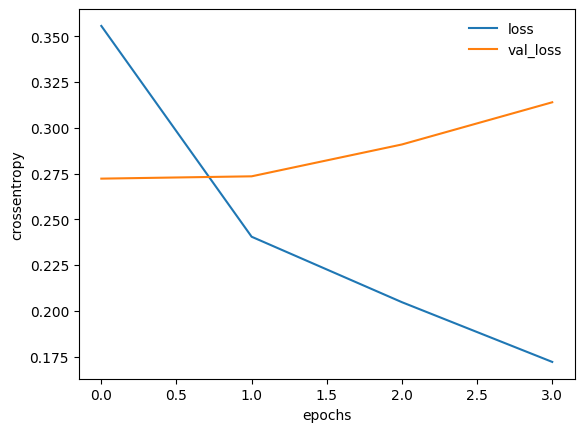

In [16]:
# グラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

初回が既に最高スコアで後は過学習のようだが、数値自体は悪くないので良しとする。

In [17]:
# predictで予測を行なう
Y_pred = model.predict(X_test)

193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step


In [18]:
# Y_predを表示
Y_pred

array([[2.6168686e-01],
       [8.3229505e-04],
       [9.5768976e-01],
       ...,
       [9.9661219e-01],
       [9.1022068e-01],
       [8.9993483e-01]], dtype=float32)

In [19]:
# 予測結果の確率が0.5以下なら0, それより大きければ1となる計算で求める
Y_pred_cls = (Y_pred > 0.5).astype("int32")
Y_pred_cls

array([[0],
       [0],
       [1],
       ...,
       [1],
       [1],
       [1]], dtype=int32)

In [20]:
# モデルの評価
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred_cls))

              precision    recall  f1-score   support

           0       0.86      0.69      0.77      1649
           1       0.89      0.96      0.93      4499

    accuracy                           0.89      6148
   macro avg       0.88      0.83      0.85      6148
weighted avg       0.89      0.89      0.88      6148

